In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra
using DifferentialEquations, StaticArrays
using StatsBase

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


# Camp fixe, canvi v

In [18]:
fixed_source = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :active => Bool,

        :S => Float64,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64
        
    ),

    model = Dict(

        :Dr_run => Float64,
        :Dr_tumble => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium => Float64,
        :delta => Float64,

        :sigma => Float64, #Gaussian width. 
        :R_source => Float64
    ),

    # medium = Dict(
    #     :mm => Float64
    # ),

    agentODE = quote  

        r = sqrt((x)^2 + (y)^2)
        ll = sqrt(DMedium / delta)

        # evitar singularidad en r=0
        r_eff = max(r, 1e-3)

        mm = 1.0 * besselk(0, r_eff / ll)

        F = ε0 + ε1 * methyl + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) 

        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)        #Energia lliure en estat adaptat

        mx = (ε0 + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) - F0) / (- ε1)

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))      #CheYp segons activitat receptor

        dt(x) = vx 
        dt(y) = vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)        #Methylation
        
    end,

    agentRule = quote

        v_run = v
        v_tumble = 0.25 

        speed = active ? v_run : v_tumble

        # Dr_tumble = 6.2      
        Dr_total = active ? Dr_run : Dr_tumble

        if active 
            λ = ωFrec*exp(-G)
            P = 1 - exp(-λ * dt)
                
        else
            λ = ωFrec*exp(G)
            P = 1 - exp(-λ * dt)  
                
        end


        if active 
            λrt = ωFrec*exp(-G) 

            P_rt = 1 - exp(-λrt * dt)
            P = rand() 
                                                #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
            if P < P_rt             #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                active = false
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()           #Tumble = random reorientation
            else     #Si rate baixa 
                active = true
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()       #Keep running, reorientation according to rotational difusion
            end

        else
            λtr = ωFrec*exp(G) 
            P_tr = 1 - exp(-λtr * dt)
            P = rand()

            if P < P_tr
                active = true
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()
            else
                active = false
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()
            end
        end
    end,
    
    agentAlg = CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Euler(),
    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=10)
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	M (Float64 agent)
	d (Float64 agent)
	active (Bool agent)
	v (Float64 agent)
	λ (Float64 agent)
	F (Float64 agent)
	A (Float64 agent)
	methyl (Float64 agent)
	vx (Float64 agent)
	l (Float64 agent)
	m (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	G (Float64 agent)
	vy (Float64 agent)
	S (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Z (Float64 model)
	Dr_run (Float64 model)
	Dr_tumble (Float64 model)
	Ka (Float64 model)
	R_source (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	DMedium (Float64 model)
	delta (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	ε2 (Float64 model)
	Nrec (Float64 model)
	sigma (Float64 model)
	τm (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)


UPDATE RULES
agentRule
 begin
    v_run = v
    v_tumble = 0.25
    speed = if active
            v_run
        else
            v_tumble
        end
    Dr_total

In [4]:
function meshgrid(x, y)
    X = repeat(x', length(y), 1)
    Y = repeat(y, 1, length(x))
    return X, Y
end

meshgrid (generic function with 1 method)

In [5]:
com = Community(
    fixed_source,
    N=1000,
    dt=0.01,
    simBox = [-100.0 100.0; -100.0 100.0],
    NMedium = [100, 100]
)

m = 1/100
g = 1/10000
d = 1

com.Dr_run = 0.062

# com.v = 100.0    #Velocitat bacteries biològica
# com.v = 90.0
# com.v = 80.0
# com.v = 75.0  #Velocitat bacteries biològica
# com.v = 60.0
# com.v = 50.0
# com.v = 20.0
com.v = 10.0
# com.v = 5.0

com.τm = 1
# com.τm = 5.0
# com.τm = 10.0
# com.τm = 30.0

com.ωFrec = 1.3
com.Ki = 0.0182
com.Ka = 3.0
com.Nrec = 6.0
com.ε0   = 6.0
com.ε1   = -1.0
com.ε2   = 80
com.ε3   = 80

com.α   = 6.0

com.K = 2.0 

com.Ky = 100.0
com.Kz = 10.0
com.Z = 5.0
com.Yy = 0.1

com.m = 1.        
com.d = 1.        
com.l = 3;

com.DMedium = 2.5
com.delta = 0.04

# com.x = rand(Uniform(com.simBox[1,:]...),com.N)
# com.y = rand(Uniform(com.simBox[2,:]...),com.N)
# com.x = 2.5*sqrt(com.DMedium/com.delta)
# com.y = 2.5*sqrt(com.DMedium/com.delta)
# com.x = 40
# com.y = 40
# com.theta = rand(Uniform(0,2π),com.N)

# Circle start
r = 2.5 * sqrt(com.DMedium / com.delta)

com.theta = rand(Uniform(0, 2π), com.N)

com.x = r .* cos.(com.theta)
com.y = r .* sin.(com.theta)

com.methyl .= 0.0
com.Yp .= com.K

com.active .= true 


1000-element Vector{Bool}:
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 ⋮
 1
 1
 1
 1
 1
 1
 1
 1
 1

In [6]:
outfile = "fsb_circle_4.jld2"
steps = 30000

loadToPlatform!(com, preallocateAgents=1000)

jldopen(outfile, "w") do file

    for step in 1:steps
        CellBasedModels.step!(com)

        stepname = @sprintf("step_%06d", step)
        g = JLD2.Group(file, stepname)

        # Agent-level arrays (length = N)
        g["x"] = copy(com.x)
        g["y"] = copy(com.y)
        g["theta"] = copy(com.theta)
    end
end


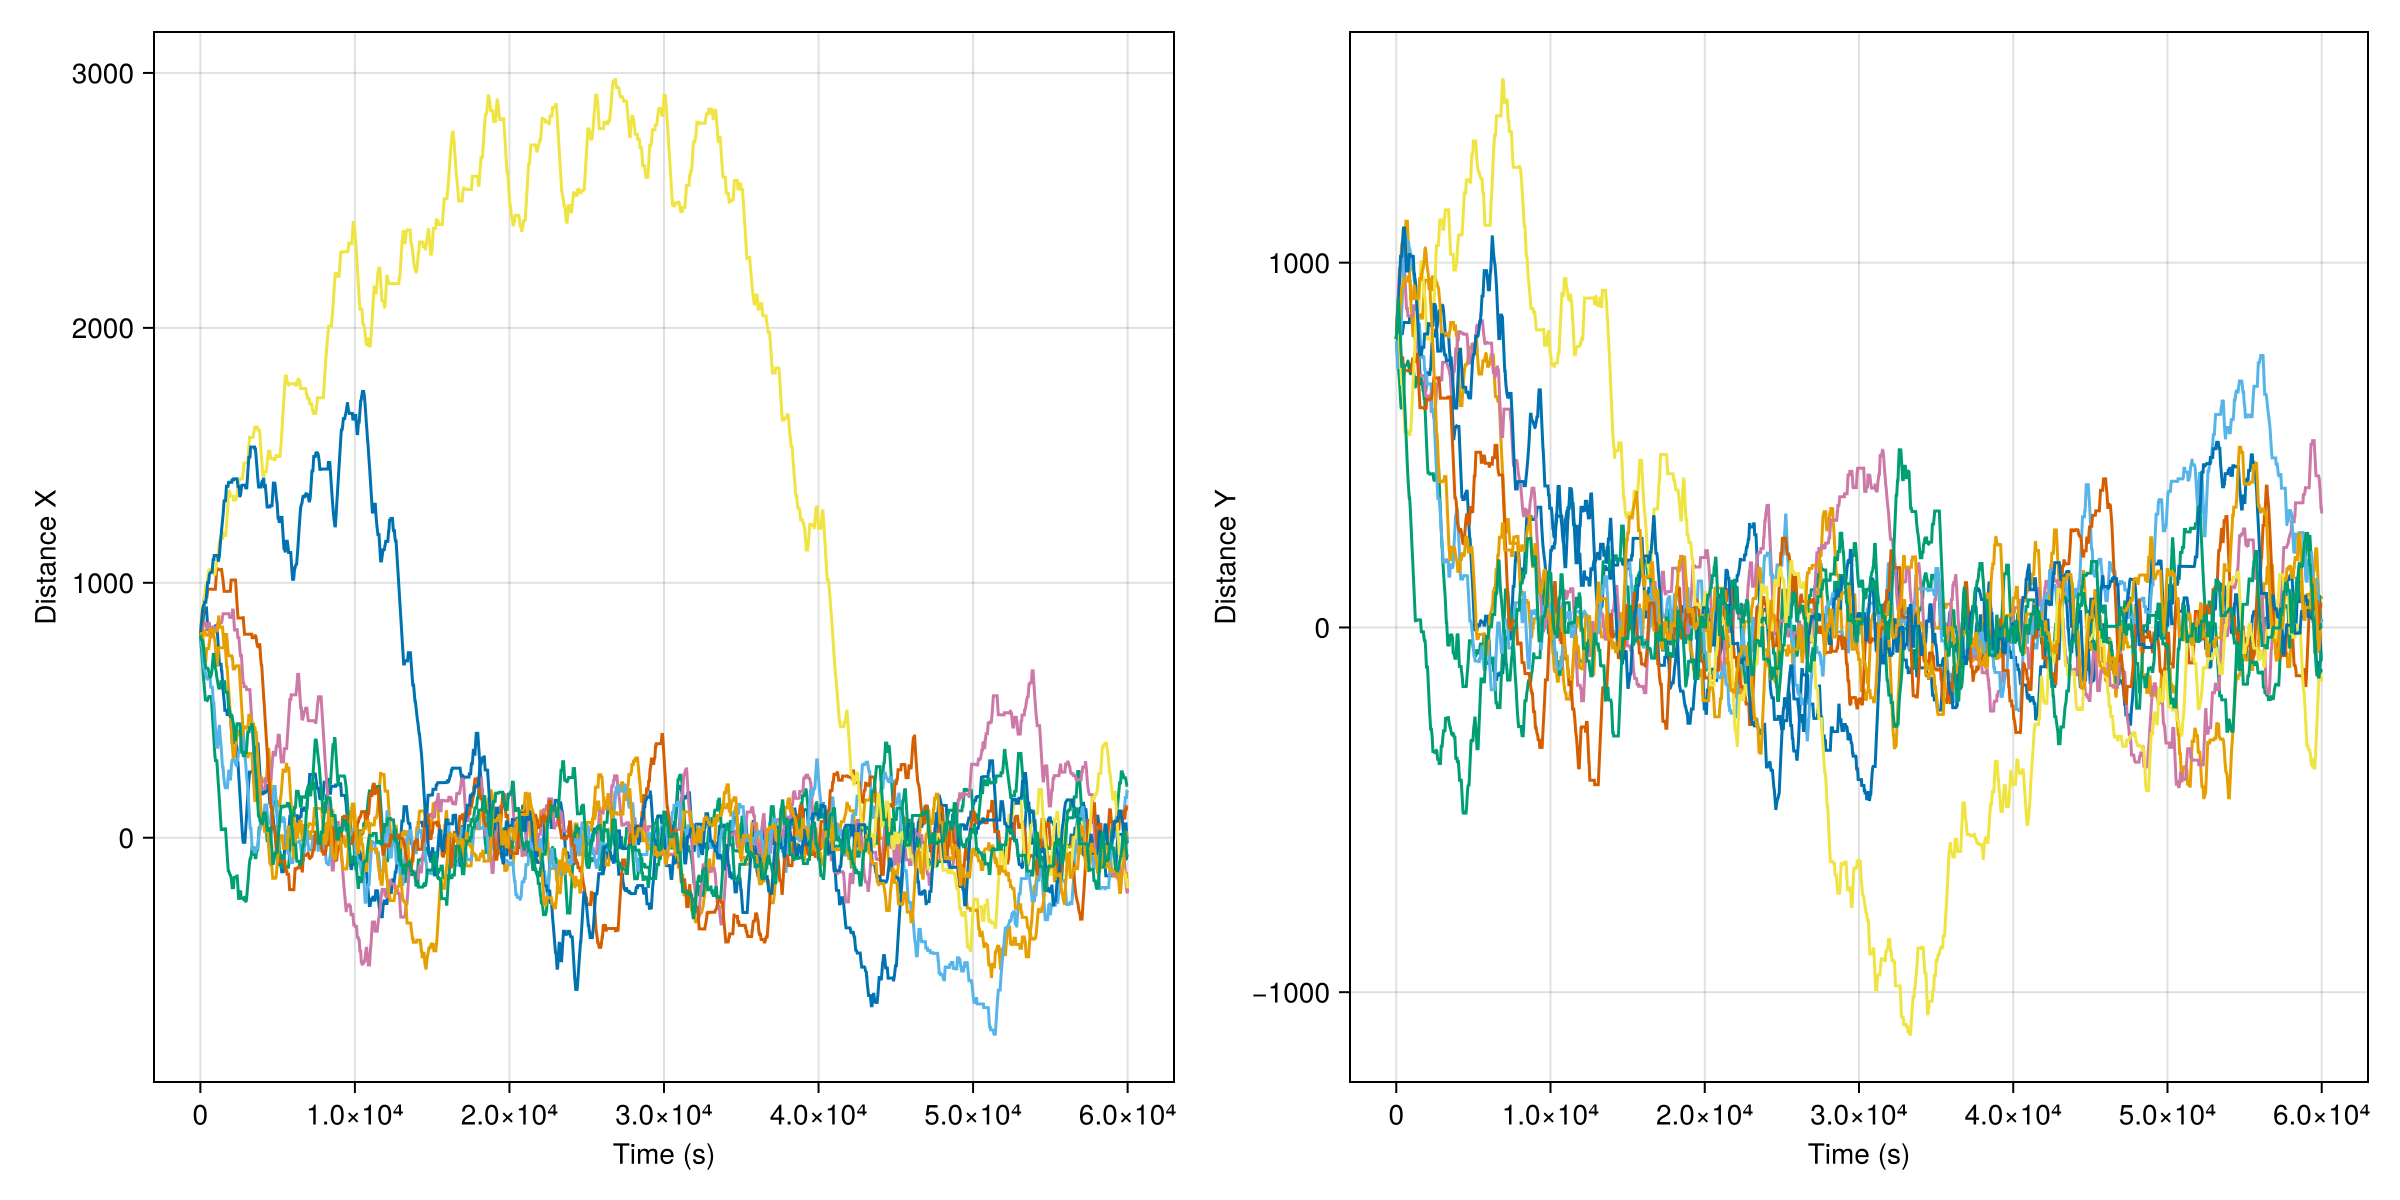

CairoMakie.Screen{IMAGE}


In [40]:
fig3 = Figure(size=(1200, 600))
ax1 = Axis(fig3[1,1], xlabel="Time (s)", ylabel="Distance X")
ax2 = Axis(fig3[1,2], xlabel="Time (s)", ylabel="Distance Y")

steps = 60000

jldopen("fsb_v100l_tm_0.1.jld2", "r") do file 
    for agent in 1:10
        x = Float64[] 
        y = Float64[]

        for step in 1:steps
            g = file[@sprintf("step_%06d", step)]

            src = 1

            xs = 0
            ys = 0

            x_1 = g["x"][agent]
            y_1 = g["y"][agent]

            # dist = abs(sqrt((x_1 - xs)^2 + (y_1 - ys)^2))
            dist = x_1 - xs
            dist_2 = y_1 - ys

            push!(x, dist)
            push!(y, dist_2)
    

        end

        # lines!(ax1, 1:steps, log.(x))
        lines!(ax1, 1:steps, x)
        lines!(ax2, 1:steps, y)
        
    end

end
display(fig3)

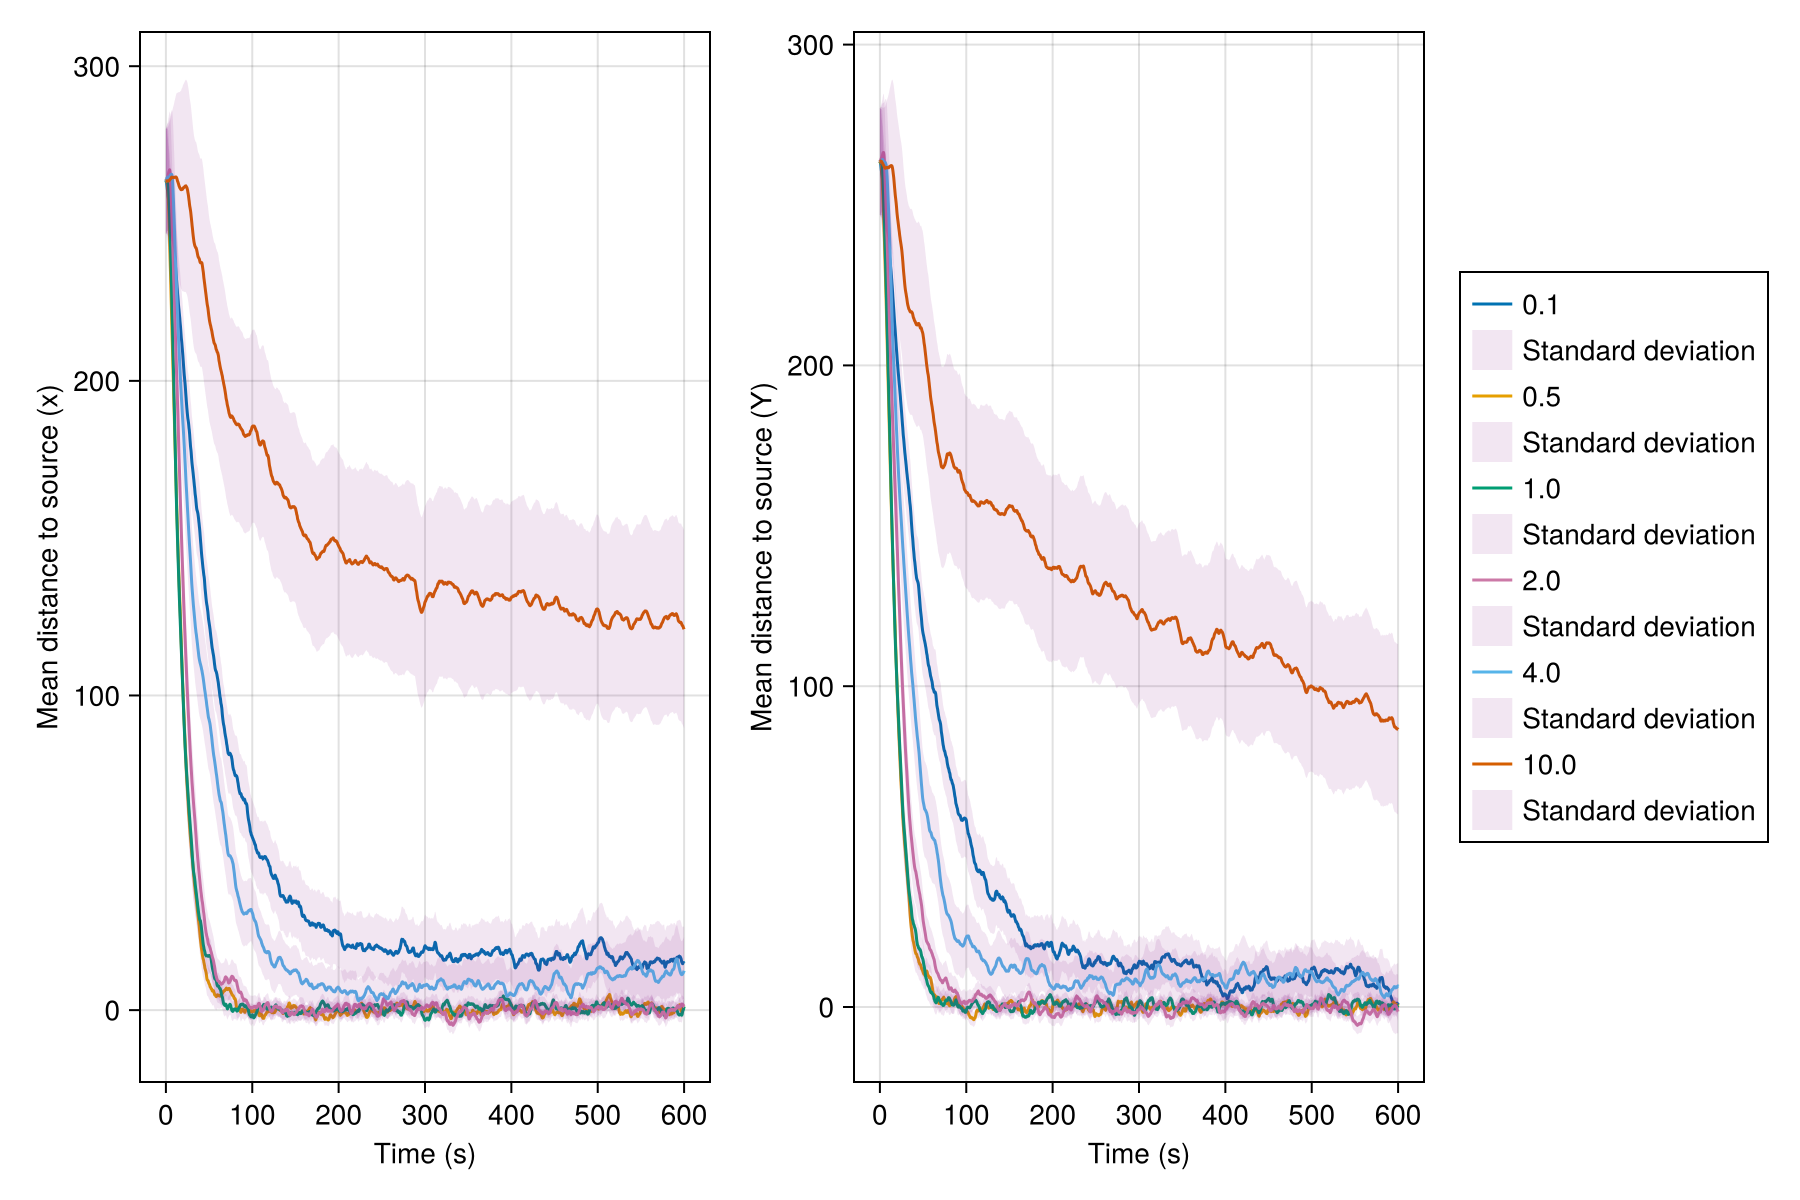

CairoMakie.Screen{IMAGE}


In [34]:
fig3 = Figure(size=(900, 600))
ax1 = Axis(fig3[1,1], xlabel="Time (s)", ylabel="Mean distance to source (x)")
ax2 = Axis(fig3[1,2], xlabel="Time (s)", ylabel="Mean distance to source (Y)")
steps = 60000

# v = [5.0, 10.0,  20.0, 100.0]
tms = [0.1, 0.5, 1.0, 2.0, 4.0, 10.0]


# for j in 1:2
    for i in 1:length(tms)

    mean_dist_x = Float64[] 
    std_dist_x = Float64[]
    mean_dist_y = Float64[] 
    std_dist_y = Float64[]
    jldopen("fsb_v100l_tm_$(tms[i]).jld2", "r") do file 

        for step in 1:steps
            g = file[@sprintf("step_%06d", step)]

            xs = 0
            ys = 0

            other_x = g["x"]

            other_y = g["y"]

            dists_x = other_x .- xs
            dists_y = other_y .- ys
            norm_x = dists_x
            norm_y = dists_y 

            push!(mean_dist_x, mean(norm_x))
            push!(std_dist_x, std(norm_x))
            push!(mean_dist_y, mean(norm_y))
            push!(std_dist_y, std(norm_y))

        end

        std_X = std_dist_x ./ sqrt(500)
        std_Y = std_dist_y ./ sqrt(500)

        lines!(ax1, (1:steps)*0.01, mean_dist_x, label = "$(tms[i])")
        band!(ax1, (1:steps)*0.01, mean_dist_x .- std_X, mean_dist_x .+ std_X, color=(:purple, 0.1), label = "Standard deviation")
        
        lines!(ax2, (1:steps)*0.01, mean_dist_y)
        band!(ax2, (1:steps)*0.01, mean_dist_y .- std_Y, mean_dist_y .+ std_Y, color=(:purple, 0.1), label = "Standard deviation") 
    end
    # end
end
fig3[1,3] = Legend(fig3, ax1) 

display(fig3)

In [36]:
save("Plots/Fixed_source_model/Next/vl_tms_3_v100.png", fig3)

In [ ]:
# ns = [0.0125, 0.025, 0.05, 0.1, 0.2]
steps = 100000
vel = [10.0, 20.0, 50.0, 60.0, 75.0, 80.0, 90.0, 100.0]


# for n in ns
    for (idx, v) in enumerate(vel)
        println("Running n=$v")

        com = Community(
            fixed_source,
            N=500,
            dt=0.01,
            simBox = [-100.0 100.0; -100.0 100.0],
            NMedium = [100, 100]
        )   

        m = 1/100
        g = 1/10000
        d = 1

        com.Dr_run = 0.062

        com.v = v 

        com.ωFrec = 1.3
        com.Ki = 0.0182
        com.Ka = 3.0
        com.Nrec = 6.0
        com.ε0   = 6.0
        com.ε1   = -1.0
        com.ε2   = 80
        com.ε3   = 80

        com.τm = 1  

        com.α   = 6.0

        com.K = 2.0 

        com.Ky = 100.0
        com.Kz = 10.0
        com.Z = 5.0
        com.Yy = 0.1

        com.m = 1.        
        com.d = 1.        
        com.l = 3;

        # Dc = 10 
        # delta = 0.01

        # d = delta/((v/10)^2)

        #Canviar lambda

        com.DMedium = 13.33
        com.delta = 0.000075

        com.x = 2.5*sqrt(com.DMedium/com.delta)
        com.y = 2.5*sqrt(com.DMedium/com.delta)
        com.theta = rand(Uniform(0,2π),com.N)

        com.methyl .= 0.0
        com.Yp .= com.K


        loadToPlatform!(com, preallocateAgents=1000)
        
        outfile = @sprintf("fsb_v%s_l421_D.jld2", v)  ###CANVIARRR NOOM

        jldopen(outfile, "w") do file

            for step in 1:steps
                CellBasedModels.step!(com)

                stepname = @sprintf("step_%06d", step)
                g = JLD2.Group(file, stepname)

                # Agent-level arrays (length = N)
                g["x"] = copy(com.x)
                g["y"] = copy(com.y)
                g["theta"] = copy(com.theta)

    
            end
        end
    end
# end

Running n=10.0
Running n=20.0
Running n=50.0
Running n=60.0
Running n=75.0
Running n=80.0
Running n=90.0
Running n=100.0


## Extract trajectories

In [4]:
dfs_l158 = Dict{Int64, DataFrame}()

vs = [5, 10, 20, 50, 75, 100]
# tms = [2.0, 1.0, 0.5, 0.1]

# vel_1 = [20.0, 50.0, 60.0, 75.0, 80.0, 100.0]
# vel_1 = [20.0, 50.0, 60.0, 75.0]
N_agents = 500
end_step = 60000

for (v_idx, v) in enumerate(vs)

    # filename = @sprintf("fsb_eff_v$s.jld2", vs[v_idx], tms[v_idx])
    println("Processing $v")

        # -----------------------------
        # STEP 2: extract trajectories
        # -----------------------------
    steps_vec = Int[]
    agents_vec = Int[]
    x_vec = Float64[]
    y_vec = Float64[]
        
    jldopen("fsb_eff_v$v.jld2", "r") do file
        for agent in 1:500
            for step in 1:10:end_step
                g = file[@sprintf("step_%06d", step)]

                push!(steps_vec, step)
                push!(agents_vec, agent)
                push!(x_vec, g["x"][agent])
                push!(y_vec, g["y"][agent])
            end
        end
    end

    df = DataFrame(
        step = steps_vec,
        agent = agents_vec,
        x = x_vec,
        y = y_vec
    )

        # store in dict
    dfs_l158[v] = df

end

Processing 5
Processing 10
Processing 20
Processing 50
Processing 75
Processing 100


In [5]:
function linear_fit_mx(x, y)
    """Linear regression constrained to pass through origin: y = m*x"""
    slope = sum(x .* y) / sum(x.^2)
    return slope
end

linear_fit_mx (generic function with 1 method)

In [6]:
times = zeros(5, 2)
times[:, 1] = [10, 20, 50, 75,  100]
times[:, 2] = [40000, 20000, 20000, 20000, 20000]


5-element Vector{Int64}:
 40000
 20000
 20000
 20000
 20000

In [11]:
# metrics_l158 = DataFrame(
#     v = Int64[],
#     mu_x = Float64[],
#     mu_y = Float64[],
#     sigma = Float64[],
#     variance = Float64[],
#     k = Float64[],
#     D = Float64[],
#     D_2 = Float64[]
# )



# vel_1 = [10, 20, 50, 60, 75, 80, 100]
vel_1 = [100]
cosa = []
fig = Figure(size=(900, 500))
for i in 1
    df = dfs_l158[vel_1[i]]

    eq_step = 20000

    eq = df[df.step .>= eq_step, :]

    mu_x = mean(eq.x)
    mu_y = mean(eq.y)
    sigma_x = std(eq.x)
    sigma_y = std(eq.y)
    var_x = varm(eq.x, 0)
    var_y =  varm(eq.y, 0)

    sigma = (sigma_x + sigma_y) / 2
    variance = (var_x + var_y) / 2

    len_data = length(unique(eq.step))
    lag_data = len_data - 100
    grouped_ag = groupby(eq, :agent)
    lags = (1:1:lag_data)

    correlations = zeros(length(grouped_ag), length(lags))
    correlations_y = zeros(length(grouped_ag), length(lags))

    for i in 1:length(grouped_ag)
        df_ag = grouped_ag[i]
        traj = df_ag.x
        traj_y = df_ag.y
        cor = autocor(traj, lags; demean = false)
        cor_y = autocor(traj_y, lags; demean = false)
        correlations[i, :] = cor
        correlations_y[i, :] = cor_y
    end

    correlations_mean = Float64[]
    correlations_mean_y = Float64[]

    for i in 1:length(lags)
        lag_mean = correlations[:, i]
        lag_mean_y = correlations_y[:, i]
        push!(correlations_mean, mean(lag_mean))
        push!(correlations_mean_y, mean(lag_mean_y))
    end

    logx = log.(abs.(correlations_mean))
    logy = log.(abs.(correlations_mean_y))

    time_005_x = findall(correlations_mean .<= 0.1)[1]
    time_005_y = findall(correlations_mean_y .<= 0.1)[1]

    slope_x = linear_fit_mx(lags[1:time_005_x], logx[1:time_005_x])
    slope_y = linear_fit_mx(lags[1:time_005_y], logx[1:time_005_y])
    
    k_x = -slope_x * 10
    k_y = -slope_y * 10

    # fig = Figure(size = (1800,600))
    # ax = Axis(fig[1,1])
    # ax1 = Axis(fig[1,2])


    # lines!(ax, lags, logx)
    # # lines!(ax, lags[1:time_005], logx[1:time_005], color = :red)
    # lines!(ax, lags[1:time_005], intercept_x .+ slope_x .* lags[1:time_005], color=:red, linestyle=:dash)
    # lines!(ax, lags[1:time_005_x], slope_x .* lags[1:time_005_x], color=:brown, linestyle=:dash)

    # lines!(ax1, lags, correlations_mean)
    # lines!(ax1, lags[1:time_005], exp.(intercept_x .+ slope_x .* lags[1:time_005]), color = :red, linestyle = :dash)
    # lines!(ax1, lags[1:time_005_x], exp.(slope_x .* lags[1:time_005_x]), color = :brown, linestyle = :dash)
    # lines!(ax1, lags[1:time_005], exp.(slope_x_exp .* lags[1:time_005]), color = :black, linestyle = :dash)

    k = (k_x + k_y) / 2
    D = sigma^2 * k
    D_2 = variance * k

    push!(metrics_l158, (
        vel_1[i],
        mu_x,
        mu_y,
        sigma,
        variance,
        k,
        D, 
        D_2
    ))
end


In [12]:
metrics_l158

Row,v,mu_x,mu_y,sigma,variance,k,D,D_2
,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,10,0.443525,0.607923,18.2768,334.691,0.128727,43.0001,43.0836
2,20,0.606712,0.811429,34.0184,1166.1,0.139529,161.469,162.704
3,50,1.26984,0.597321,57.1249,3279.57,0.169423,552.872,555.635
4,75,0.590468,-0.224315,62.9231,3959.51,0.187583,742.7,742.738
5,100,4.19336,5.82884,133.953,18500.5,0.181542,3257.5,3358.63


In [ ]:
using CairoMakie

lambdas = [0.5, 3.0, 8.0]
v_target = 10.0

fig = Figure(size=(1100, 500))

ax1 = Axis(fig[1, 1])
ax2 = Axis(fig[1, 2])

g1 = colorant"#28666E"
g2 = colorant"#5A8E94"
g3 = colorant"#8DB6BA"
colors = [g1, g2, g3]

for (i, λ) in enumerate(lambdas)

    df = dfs_redo[(v_target, λ)]

    # equilibrium row
    row = df_times[(df_times.v .== v_target) .& (df_times.lambda .== λ), :]
    eq_step = row.eq_time[1]

    eq = df[df.step .>= eq_step, :]

    grouped_ag = groupby(eq, :agent)

    len_data = length(unique(eq.step))
    lag_data = len_data - 100
    lags = 1:lag_data

    correlations = zeros(length(grouped_ag), length(lags))

    for j in 1:length(grouped_ag)
        traj = grouped_ag[j].x
        correlations[j, :] .= autocor(traj, lags; demean=false)
    end

    corr_mean = [mean(correlations[:, t]) for t in 1:length(lags)]
    corr_std  = [std(correlations[:, t]) for t in 1:length(lags)]

    log_corr = log.(abs.(corr_mean))

    # cutoff for fit
    cutoff = findfirst(corr_mean .<= 0.1)
    if cutoff === nothing
        cutoff = length(lags)
    end

    slope = linear_fit_mx(lags[1:cutoff], log_corr[1:cutoff])

    fit_exp = exp.(slope .* lags[1:cutoff])
    fit_log = slope .* lags[1:cutoff]

    c = colors[i]

    # =========================
    # AXIS 1: correlation space
    # =========================
    lines!(ax1, lags, corr_mean, color=c, label="λ = $λ")

    band!(ax1,
        lags,
        corr_mean .+ corr_std,
        corr_mean .- corr_std,
        color=(c, 0.15)
    )

    lines!(ax1, lags[1:cutoff], fit_exp, color=c, linestyle=:dash)

    # =========================
    # AXIS 2: log space
    # =========================
    lines!(ax2, lags, log_corr, color=c, label="λ = $λ")
    lines!(ax2, lags[1:cutoff], fit_log, color=c, linestyle=:dash)

end

# axislegend(ax1)
# axislegend(ax2)
hidedecorations!(ax1, grid = true)
hidedecorations!(ax2, grid = true)

xlims!(ax1, 0, 500)
xlims!(ax2, 0, 500)
ylims!(ax2, -6, 0)

fig

In [127]:
new = metrics_l316[3:8, :]

Row,v,mu_x,mu_y,sigma,variance,k,D,D_2
,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,50,0.174364,0.302513,56.4146,3182.65,0.148348,472.135,472.141
2,60,-0.349467,-0.0500514,64.7467,4192.15,0.152531,639.431,639.434
3,75,0.264367,-0.235722,76.1542,5799.52,0.167202,969.682,969.691
4,80,0.41721,-0.158988,79.6269,6340.45,0.1594,1010.66,1010.67
5,100,7.71165,6.78455,181.806,33297.3,0.157644,5210.67,5249.13
6,20,0.269838,0.876628,34.5593,1200.03,0.0976733,116.656,117.211


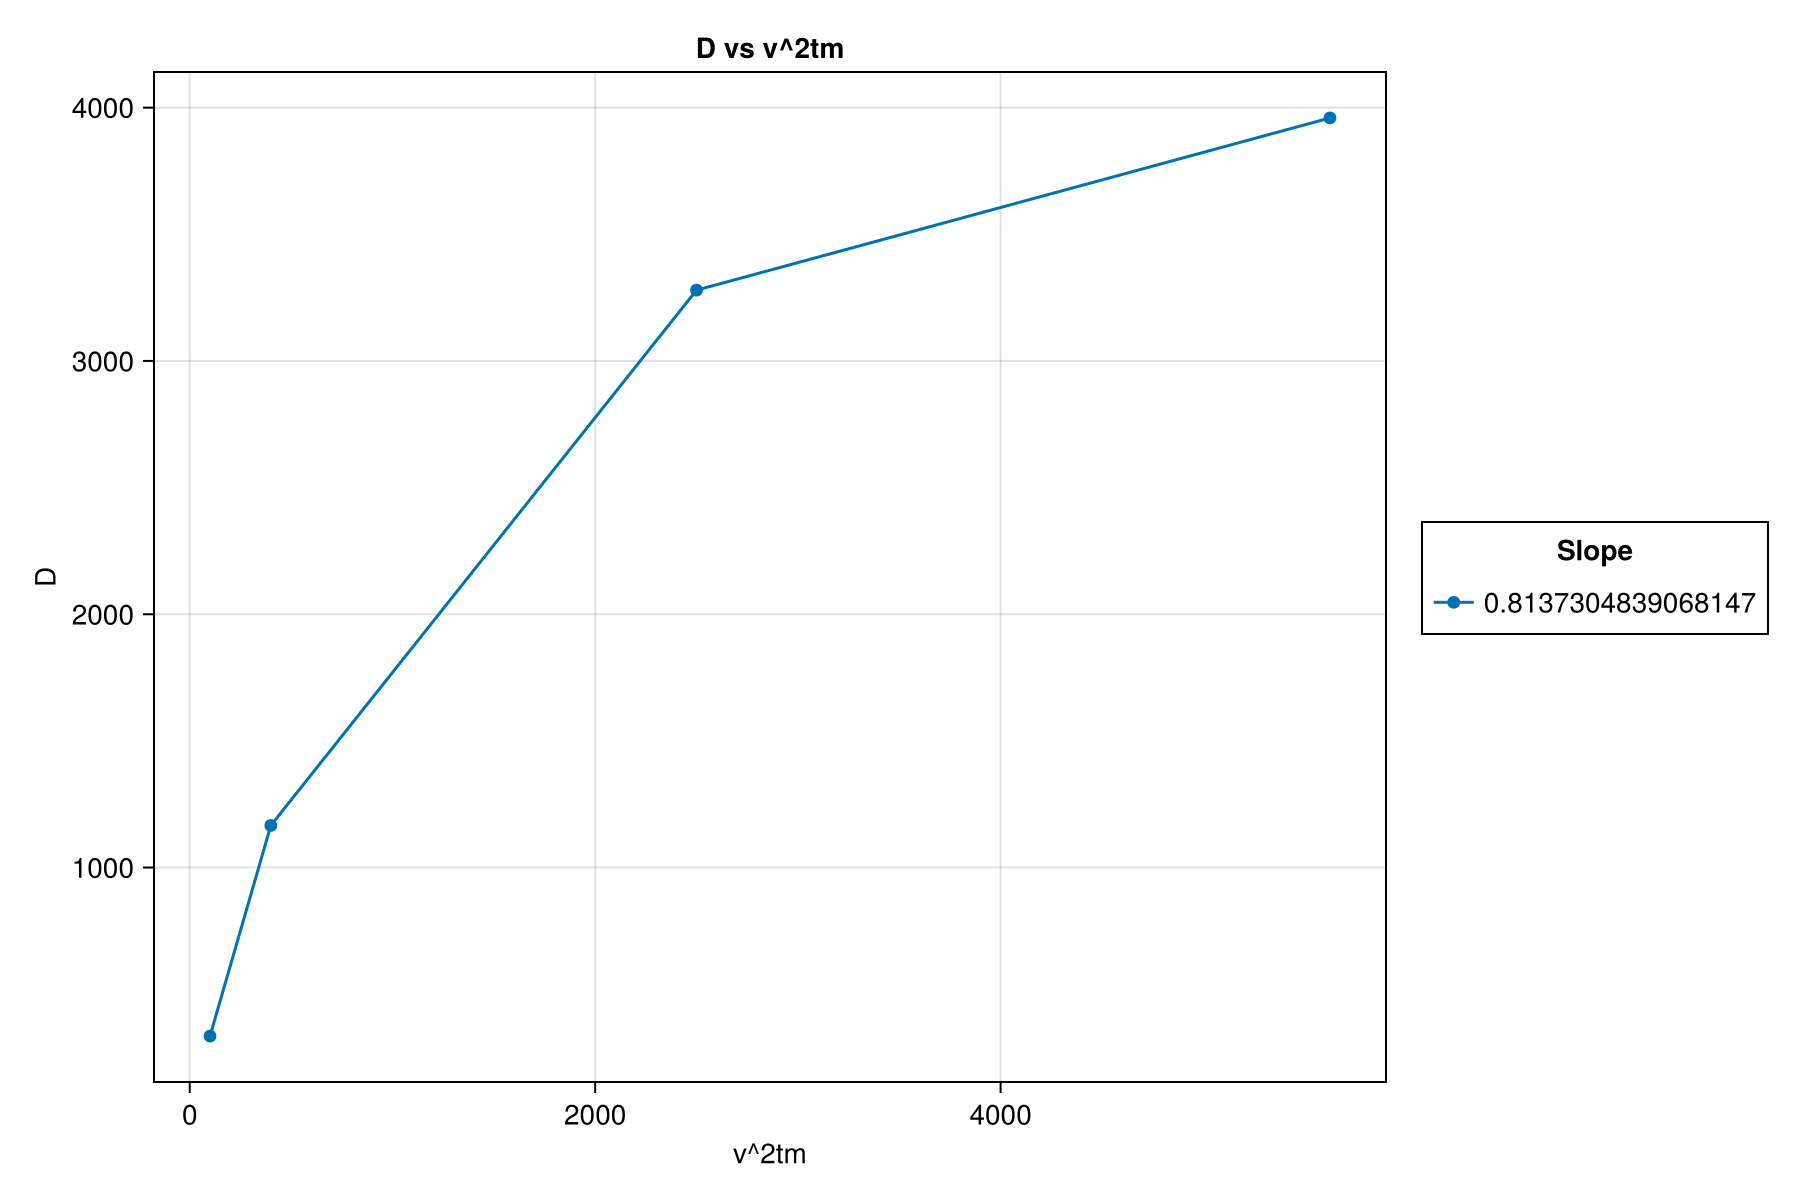

In [16]:
using CairoMakie
velocities = [10, 20, 50, 75]
diff = Float64[]
vtm = Float64[]

fig = Figure(size=(900, 600))
ax = Axis(fig[1,1], title = "D vs v^2tm", xlabel = "v^2tm", ylabel = "D")

diff = Float64[]
vtm = Float64[]
for (idx, v) in enumerate(velocities)
    mask = (metrics_l158.v .== v)
    row = metrics_l158.variance[mask]
    D = row[1]
    valor = v^2
    push!(diff, D)
    push!(vtm, valor)

end

slope = linear_fit_mx(vtm, diff)

scatterlines!(ax, vtm, diff, label = "$slope")
fig[1,2] = Legend(fig, ax, "Slope")
fig

In [64]:
slope

1.1204962923397959

In [15]:
save("Plots/Fixed_source_model/Next/l_158_Dvtm.pdf", fig)

CairoMakie.Screen{PDF}


# Lambdas petites - k fit

Lambdas: 0.025 era sa mes petita
Probam: 0.2, 0.1, 0.05, 0.025, 0.0125 (5 lambdas)
Velocitats de sempre = 5, 10, 20, 100
20 simulations - o fes 2 velocitats = 10 simulacions x 1.5 min = 15 min. 

In [43]:
# ns = [0.5]
steps = 60000
tms = [0.1, 2.0, 4.0, 10.0]
ns = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]


for n in ns
    for (idx, tm) in enumerate(tms)
        println("Running tm = $tm, n = $n")

        com = Community(
            fixed_source,
            N=500,
            dt=0.01,
            simBox = [-100.0 100.0; -100.0 100.0],
            NMedium = [100, 100]
        )   

        m = 1/100
        g = 1/10000
        d = 1

        com.Dr_run = 0.062
        com.Dr_tumble = 6.2

        com.v = 10

        com.ωFrec = 1.3
        com.Ki = 0.0182
        com.Ka = 3.0
        com.Nrec = 6.0
        com.ε0   = 6.0
        com.ε1   = -1.0
        com.ε2   = 80
        com.ε3   = 80

        com.τm = tm

        com.α   = 6.0

        com.K = 2.0 

        com.Ky = 100.0
        com.Kz = 10.0
        com.Z = 5.0
        com.Yy = 0.1

        com.m = 1.        
        com.d = 1.        
        com.l = 3;

        Dc = 10
        delta = 0.01 

        d = delta/((tm)^2)

        #Canviar lambda

        com.DMedium = Dc / n
        com.delta = d * n

        com.x = 2.5*sqrt(com.DMedium/com.delta)
        com.y = 2.5*sqrt(com.DMedium/com.delta)
        com.theta = rand(Uniform(0,2π),com.N)

        com.methyl .= 0.0
        com.Yp .= com.K


        loadToPlatform!(com, preallocateAgents=1000)
        
        outfile = @sprintf("fsb_tm_%s_n_%s.jld2", tm, n)  ###CANVIARRR NOOM

        jldopen(outfile, "w") do file

            meta = JLD2.Group(file, "meta")
            meta["DMedium"] = com.DMedium
            meta["delta"] = com.delta

            for step in 1:steps
                CellBasedModels.step!(com)
                if step%100 == 0

                    stepname = @sprintf("step_%06d", step)
                    g = JLD2.Group(file, stepname)

                    # Agent-level arrays (length = N)
                    g["x"] = copy(com.x)
                    g["y"] = copy(com.y)
                    g["theta"] = copy(com.theta)
                end
            end
        end
    end
end

Running tm = 0.1, n = 0.25
Running tm = 2.0, n = 0.25
Running tm = 4.0, n = 0.25
Running tm = 10.0, n = 0.25
Running tm = 0.1, n = 0.5
Running tm = 2.0, n = 0.5
Running tm = 4.0, n = 0.5
Running tm = 10.0, n = 0.5
Running tm = 0.1, n = 0.75
Running tm = 2.0, n = 0.75
Running tm = 4.0, n = 0.75
Running tm = 10.0, n = 0.75
Running tm = 0.1, n = 1.0
Running tm = 2.0, n = 1.0
Running tm = 4.0, n = 1.0
Running tm = 10.0, n = 1.0
Running tm = 0.1, n = 2.0
Running tm = 2.0, n = 2.0
Running tm = 4.0, n = 2.0
Running tm = 10.0, n = 2.0
Running tm = 0.1, n = 3.0
Running tm = 2.0, n = 3.0
Running tm = 4.0, n = 3.0
Running tm = 10.0, n = 3.0
Running tm = 0.1, n = 4.0
Running tm = 2.0, n = 4.0
Running tm = 4.0, n = 4.0
Running tm = 10.0, n = 4.0
Running tm = 0.1, n = 5.0
Running tm = 2.0, n = 5.0
Running tm = 4.0, n = 5.0
Running tm = 10.0, n = 5.0
Running tm = 0.1, n = 6.0
Running tm = 2.0, n = 6.0
Running tm = 4.0, n = 6.0
Running tm = 10.0, n = 6.0
Running tm = 0.1, n = 7.0
Running tm = 2.0, n =

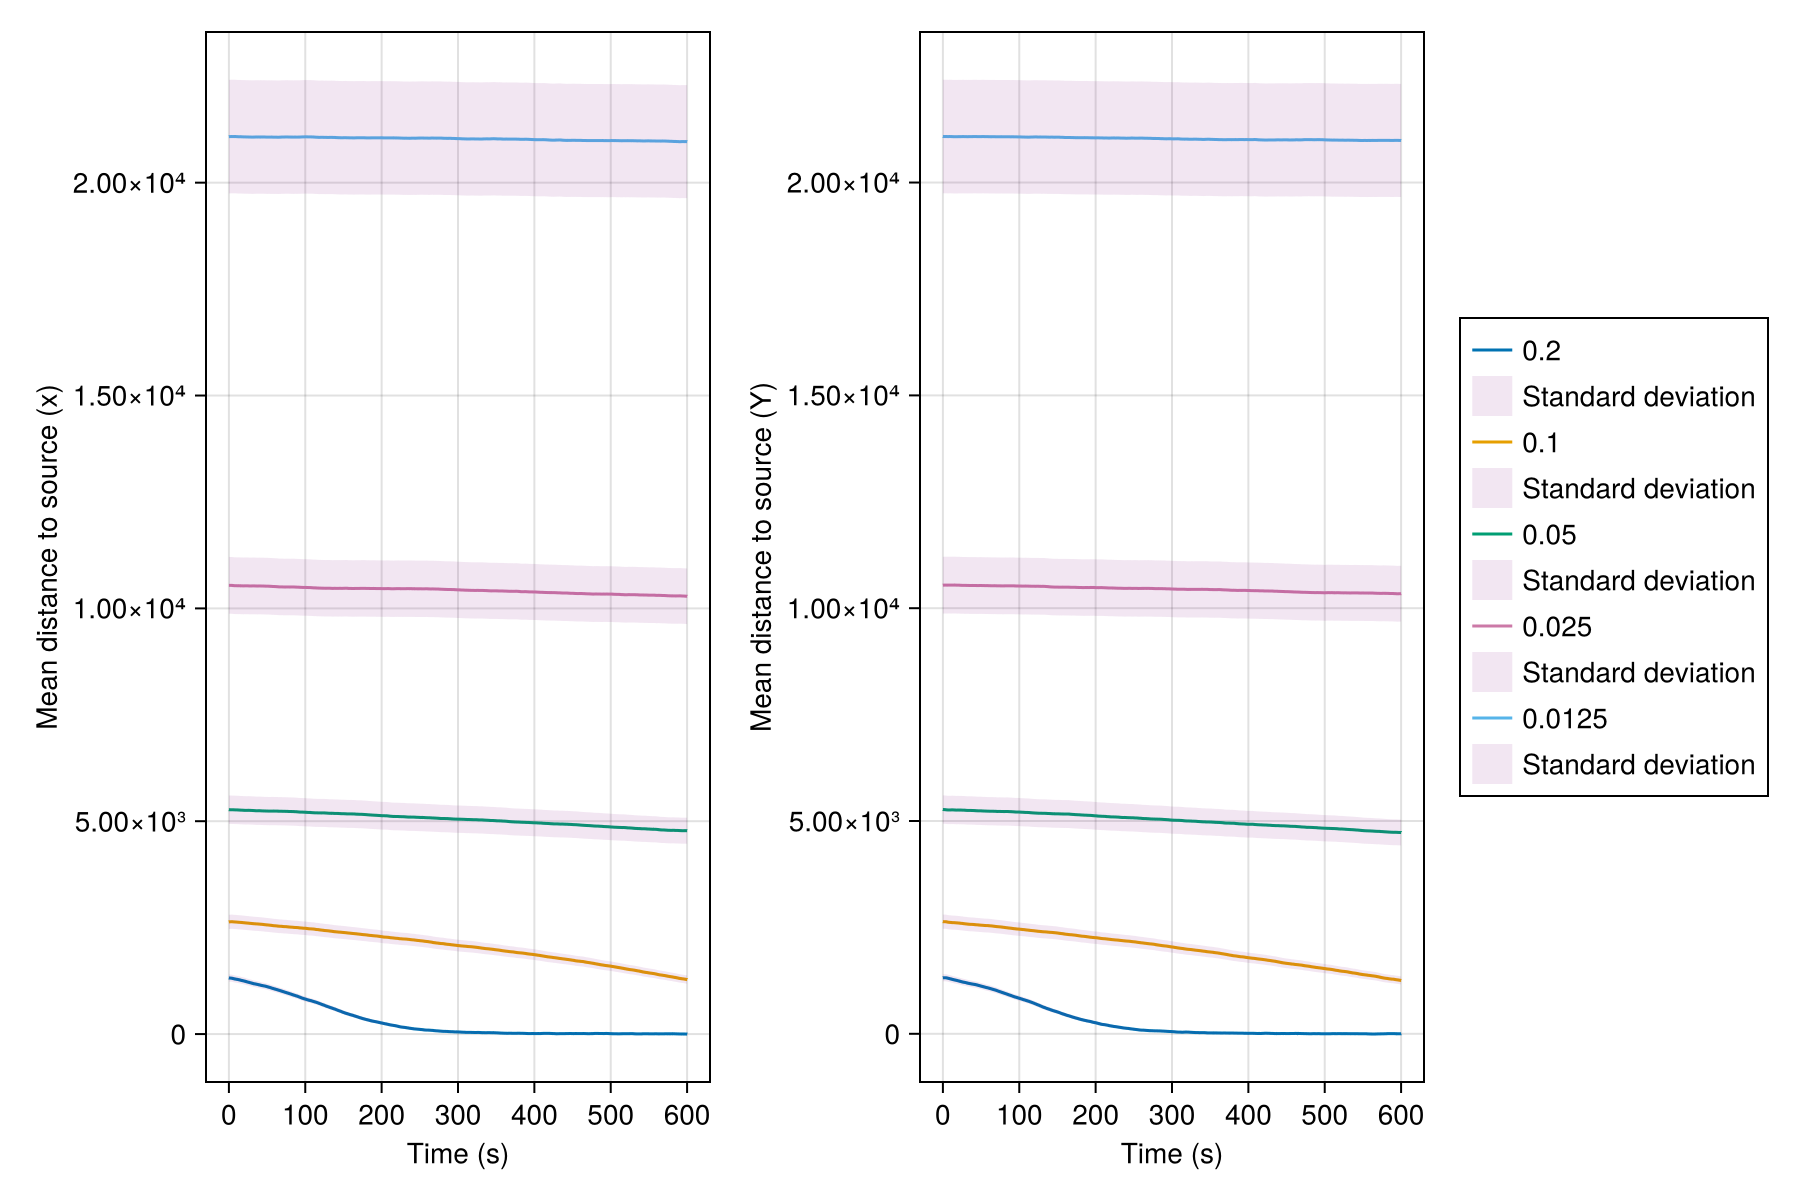

CairoMakie.Screen{IMAGE}


In [12]:
using CairoMakie
fig3 = Figure(size=(900, 600))
ax1 = Axis(fig3[1,1], xlabel="Time (s)", ylabel="Mean distance to source (x)")
ax2 = Axis(fig3[1,2], xlabel="Time (s)", ylabel="Mean distance to source (Y)")
steps = 60000

v = [5, 10, 20, 50, 100]
ls = [0.2, 0.1, 0.05, 0.025, 0.0125]

for i in 1:length(ls)

    mean_dist_x = Float64[] 
    std_dist_x = Float64[]
    mean_dist_y = Float64[] 
    std_dist_y = Float64[]
    jldopen("fsb_v100.0_l$(ls[i])_k.jld2", "r") do file 

        for step in 1:steps
            g = file[@sprintf("step_%06d", step)]

            xs = 0
            ys = 0

            other_x = g["x"]

            other_y = g["y"]

            dists_x = other_x .- xs
            dists_y = other_y .- ys
            norm_x = dists_x
            norm_y = dists_y

            push!(mean_dist_x, mean(norm_x))
            push!(std_dist_x, std(norm_x))
            push!(mean_dist_y, mean(norm_y))
            push!(std_dist_y, std(norm_y))

        end

        std_X = std_dist_x ./ sqrt(500)
        std_Y = std_dist_y ./ sqrt(500)

        lines!(ax1, (1:steps)*0.01, mean_dist_x, label = "$(ls[i])")
        band!(ax1, (1:steps)*0.01, mean_dist_x .- std_X, mean_dist_x .+ std_X, color=(:purple, 0.1), label = "Standard deviation")
        
        lines!(ax2, (1:steps)*0.01, mean_dist_y)
        band!(ax2, (1:steps)*0.01, mean_dist_y .- std_Y, mean_dist_y .+ std_Y, color=(:purple, 0.1), label = "Standard deviation") 

    end
end
fig3[1,3] = Legend(fig3, ax1) 

display(fig3)

In [13]:
CairoMakie.save("Plots/Fixed_source_model/Next/n_small_v100_k.svg", fig3)

CairoMakie.Screen{SVG}


In [93]:
dfs_lambda = Dict{Float64, DataFrame}()


# vel = [10.0, 20.0, 50.0, 100.0]
lambdas = [0.2, 0.1]
N_agents = 500
end_step = 60000

for (l_idx, l) in enumerate(lambdas)

    filename = @sprintf("fsb_v10.0_l%s_k.jld2", l)
    println("Processing $filename")

        # -----------------------------
        # STEP 2: extract trajectories
        # -----------------------------
    steps_vec = Int[]
    agents_vec = Int[]
    x_vec = Float64[]
    y_vec = Float64[]
        
    jldopen(filename, "r") do file
        for agent in 1:500
            for step in 1:10:end_step
                g = file[@sprintf("step_%06d", step)]

                push!(steps_vec, step)
                push!(agents_vec, agent)
                push!(x_vec, g["x"][agent])
                push!(y_vec, g["y"][agent])
            end
        end
    end

    df = DataFrame(
        step = steps_vec,
        agent = agents_vec,
        x = x_vec,
        y = y_vec
    )

        # store in dict
    dfs_lambda[l] = df

end

Processing fsb_v10.0_l0.2_k.jld2
Processing fsb_v10.0_l0.1_k.jld2


In [ ]:
function linear_fit(x, y)
    """Simple linear regression: y = a + b*x"""
    n = length(x)
    sum_x = sum(x)
    sum_y = sum(y)
    sum_xy = sum(x .* y)
    sum_x2 = sum(x.^2)
    
    slope = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x^2)
    intercept = (sum_y - slope * sum_x) / n
    
    return slope, intercept
end

In [203]:
times = zeros(2, 2)
times[:, 1] = [0.2, 0.1]
times[:, 2] = [40000, 50000]

2-element Vector{Int64}:
 40000
 50000

In [211]:
metrics_test = DataFrame(
    l = Float64[],
    mu_x = Float64[],
    mu_y = Float64[],
    sigma = Float64[],
    k = Float64[],
    D = Float64[]
)

lambdas = [0.1, 0.2]

for i in 1:2
    df = dfs_lambda[lambdas[i]]

    eq_step = times[i, 2]

    eq = df[df.step .>= eq_step, :]

    mu_x = mean(eq.x)
    mu_y = mean(eq.y)
    sigma_x = std(eq.x)
    sigma_y = std(eq.y)

    sigma = (sigma_x + sigma_y) / 2

    grouped_ag = groupby(eq, :agent)
    lags = (1:50:400)

    correlations = zeros(length(grouped_ag), length(lags))
    correlations_y = zeros(length(grouped_ag), length(lags))

    for i in 1:length(grouped_ag)
        df_ag = grouped_ag[i]
        traj = df_ag.x
        traj_y = df_ag.y
        cor = autocor(traj, lags; demean = false)
        cor_y = autocor(traj_y, lags; demean = false)
        correlations[i, :] = cor
        correlations_y[i, :] = cor_y
    end

    correlations_mean = Float64[]
    correlations_mean_y = Float64[]

    for i in 1:length(lags)
        lag_mean = correlations[:, i]
        lag_mean_y = correlations_y[:, i]
        push!(correlations_mean, mean(lag_mean))
        push!(correlations_mean_y, mean(lag_mean_y))
    end

    logx = log.(abs.(correlations_mean))
    logy = log.(abs.(correlations_mean_y))

    slope_x, intercept_x = linear_fit(lags, logx)
    slope_y, intercept_y = linear_fit(lags, logy)
    k_x = -slope_x 
    k_y = -slope_y

    k = (k_x + k_y) / 2
    D = sigma^2 * k

    push!(metrics_test, (
        lambdas[i],
        mu_x,
        mu_y,
        sigma,
        k,
        D
    ))
end

In [100]:
@load "metrics_redo.jld2" metrics_redo

1-element Vector{Symbol}:
 :metrics_redo

In [212]:
metrics_test

Row,l,mu_x,mu_y,sigma,k,D
,Float64,Float64,Float64,Float64,Float64,Float64
1,0.1,451.459,450.054,201.736,0.000658342,26.7928
2,0.2,0.295632,0.413672,17.0631,0.0158654,4.61922


In [197]:
metrics_lambdas

Row,l,mu_x,mu_y,sigma,k,D
,Float64,Float64,Float64,Float64,Float64,Float64
1,0.2,0.917409,0.802124,20.6406,0.002385,1.01609
2,0.1,451.459,450.054,201.736,0.00145448,59.1934
3,0.1,407.776,408.319,207.558,0.0026802,115.464
4,0.1,407.776,408.319,207.558,0.0014883,64.1167


In [263]:
mask = (metrics_redo.v .== 10.0)
rows = metrics_redo[metrics_redo.v .== 10.0, :]
k = rows.k
lambdas = rows.lambda
push!(lambdas, 0.2)
push!(lambdas, 0.1)
push!(k, metrics_lambdas.k[1])
push!(k, metrics_lambdas.k[4])

15-element Vector{Float64}:
 0.014700701102237491
 0.010411796402124526
 0.006975835388149694
 0.012426053084010211
 0.016752444079465863
 0.014992132613218828
 0.016404874830912797
 0.016187336745849972
 0.015139815847446357
 0.01364877595912192
 0.002979615371731687
 0.018090994704881614
 0.01608258851939039
 0.0023850022737745957
 0.001488302373482326

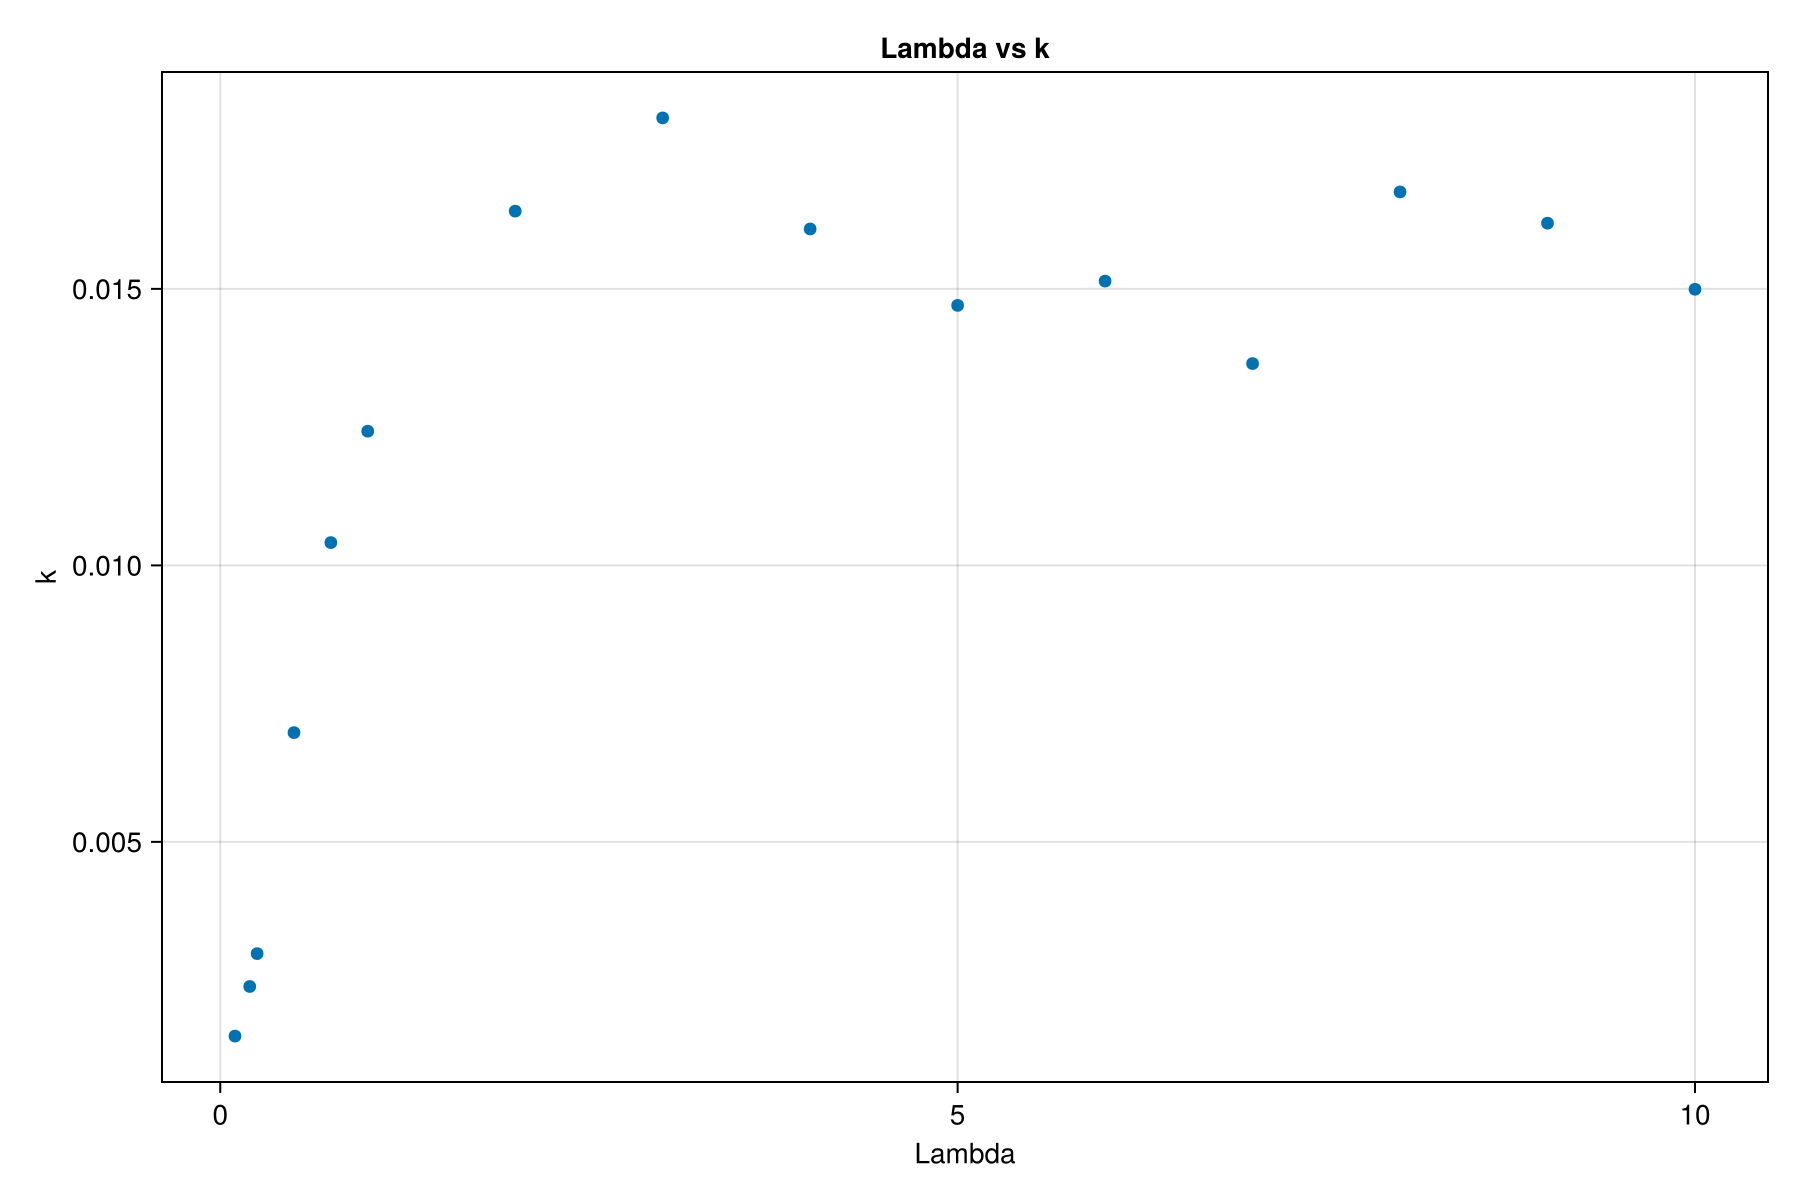

In [264]:
fig5 = Figure(size=(900, 600))
ax5 = Axis(fig5[1,1], title = "Lambda vs k", xlabel = "Lambda", ylabel = "k")
scatter!(ax5, lambdas, k)
fig5

In [258]:
save("Plots/Fixed_source_model/Next/n_small_v10_k_plot.svg", fig5)

CairoMakie.Screen{SVG}


In [271]:
ordered_k = sort(k)
first_k = ordered_k[1:6]
ordered_l = sort(lambdas)
first_l = ordered_l[1:6]

6-element Vector{Float64}:
 0.1
 0.2
 0.25
 0.5
 0.75
 1.0

0.01290965552213548 8.659490521561723e-5


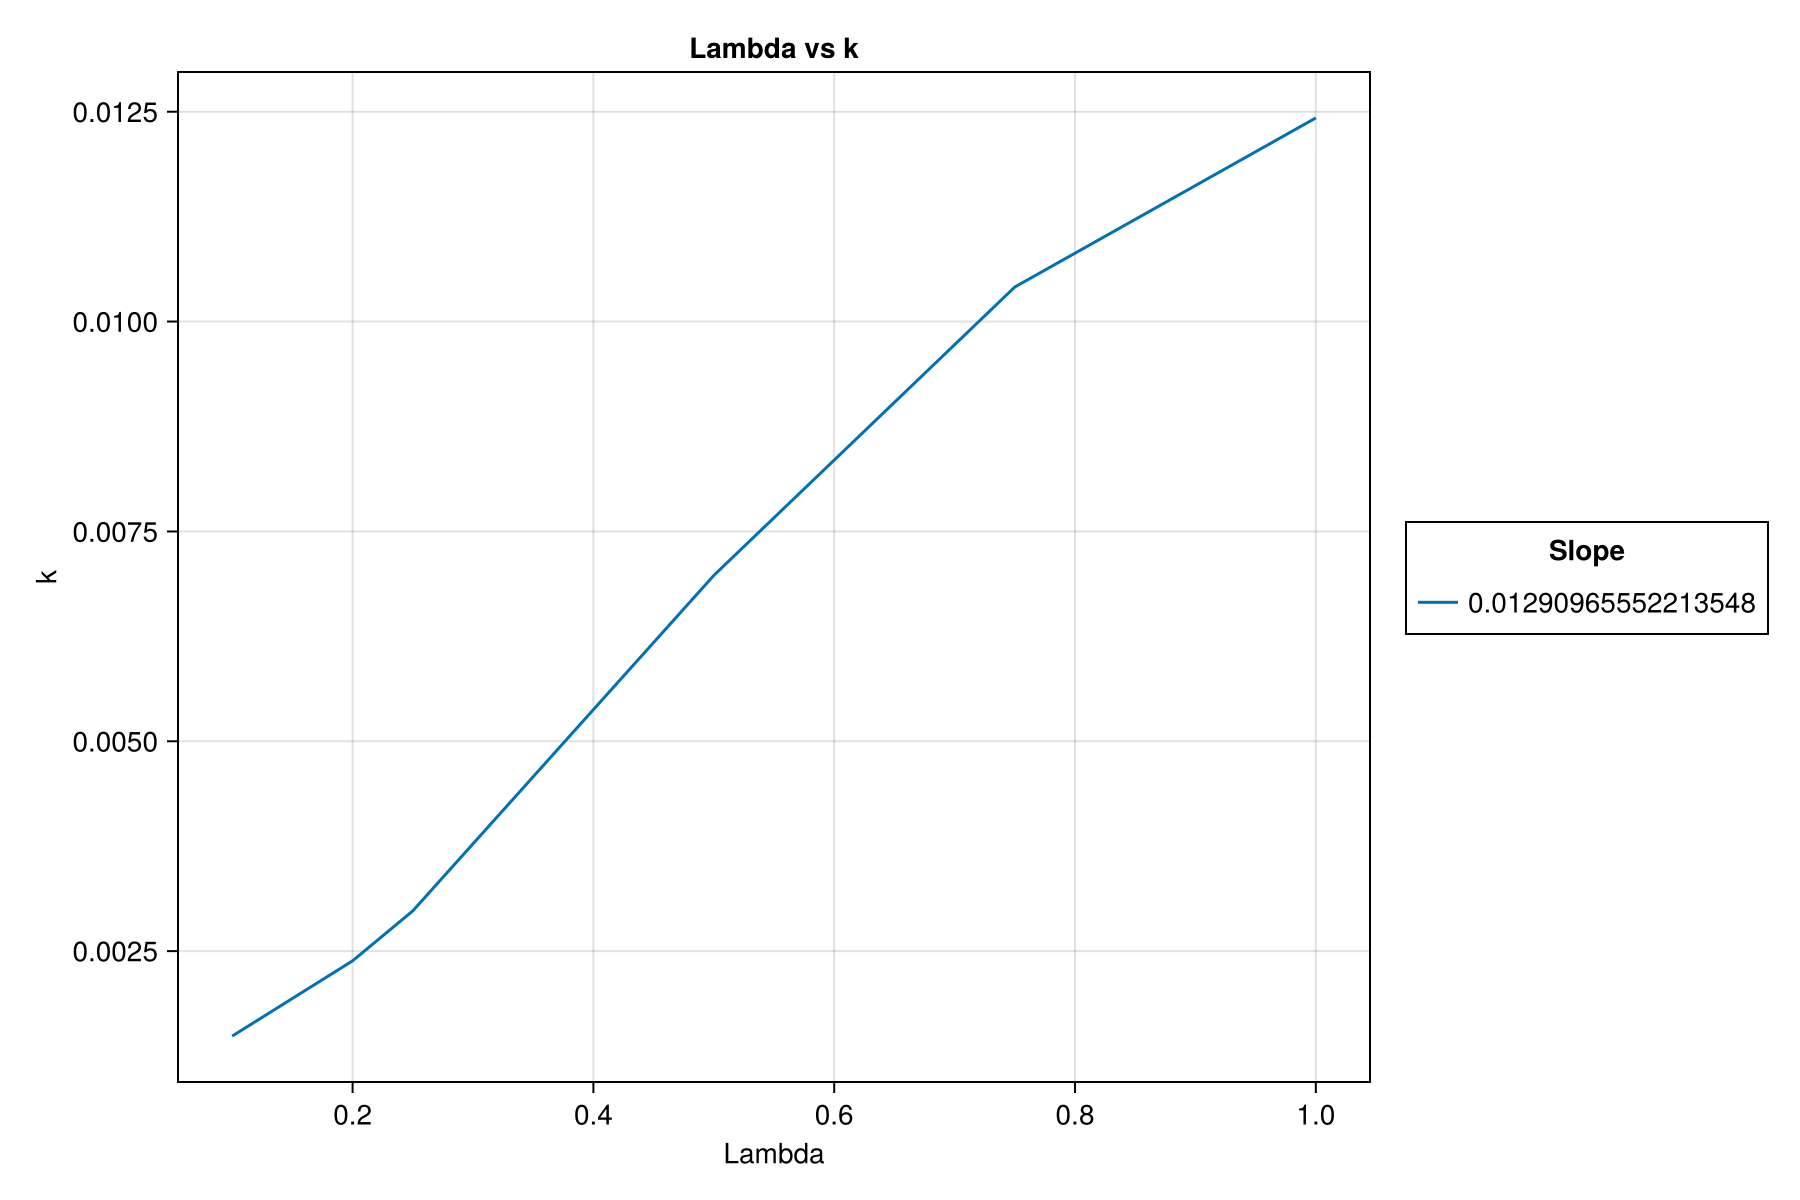

In [274]:
fig5 = Figure(size=(900, 600))
ax5 = Axis(fig5[1,1], title = "Lambda vs k", xlabel = "Lambda", ylabel = "k")
df = DataFrame(x = first_l, y = first_k)
model = lm(@formula(y ~ x), df)

a = coef(model)[2]   # slope
b = coef(model)[1]

lines!(ax5, first_l, first_k, label ="$a")


println(a, " ", b)
fig5[1,2] = Legend(fig5, ax5, "Slope")
fig5

In [275]:
save("Plots/Fixed_source_model/Next/small_lambdas_linear_fit.svg", fig5)

CairoMakie.Screen{SVG}


In [273]:
model

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

y ~ 1 + x

Coefficients:
───────────────────────────────────────────────────────────────────────────────
                  Coef.   Std. Error      t  Pr(>|t|)     Lower 95%   Upper 95%
───────────────────────────────────────────────────────────────────────────────
(Intercept)  8.65949e-5  0.000383147   0.23    0.8323  -0.000977191  0.00115038
x            0.0129097   0.000676434  19.08    <1e-04   0.0110316    0.0147877
───────────────────────────────────────────────────────────────────────────────

# Fields

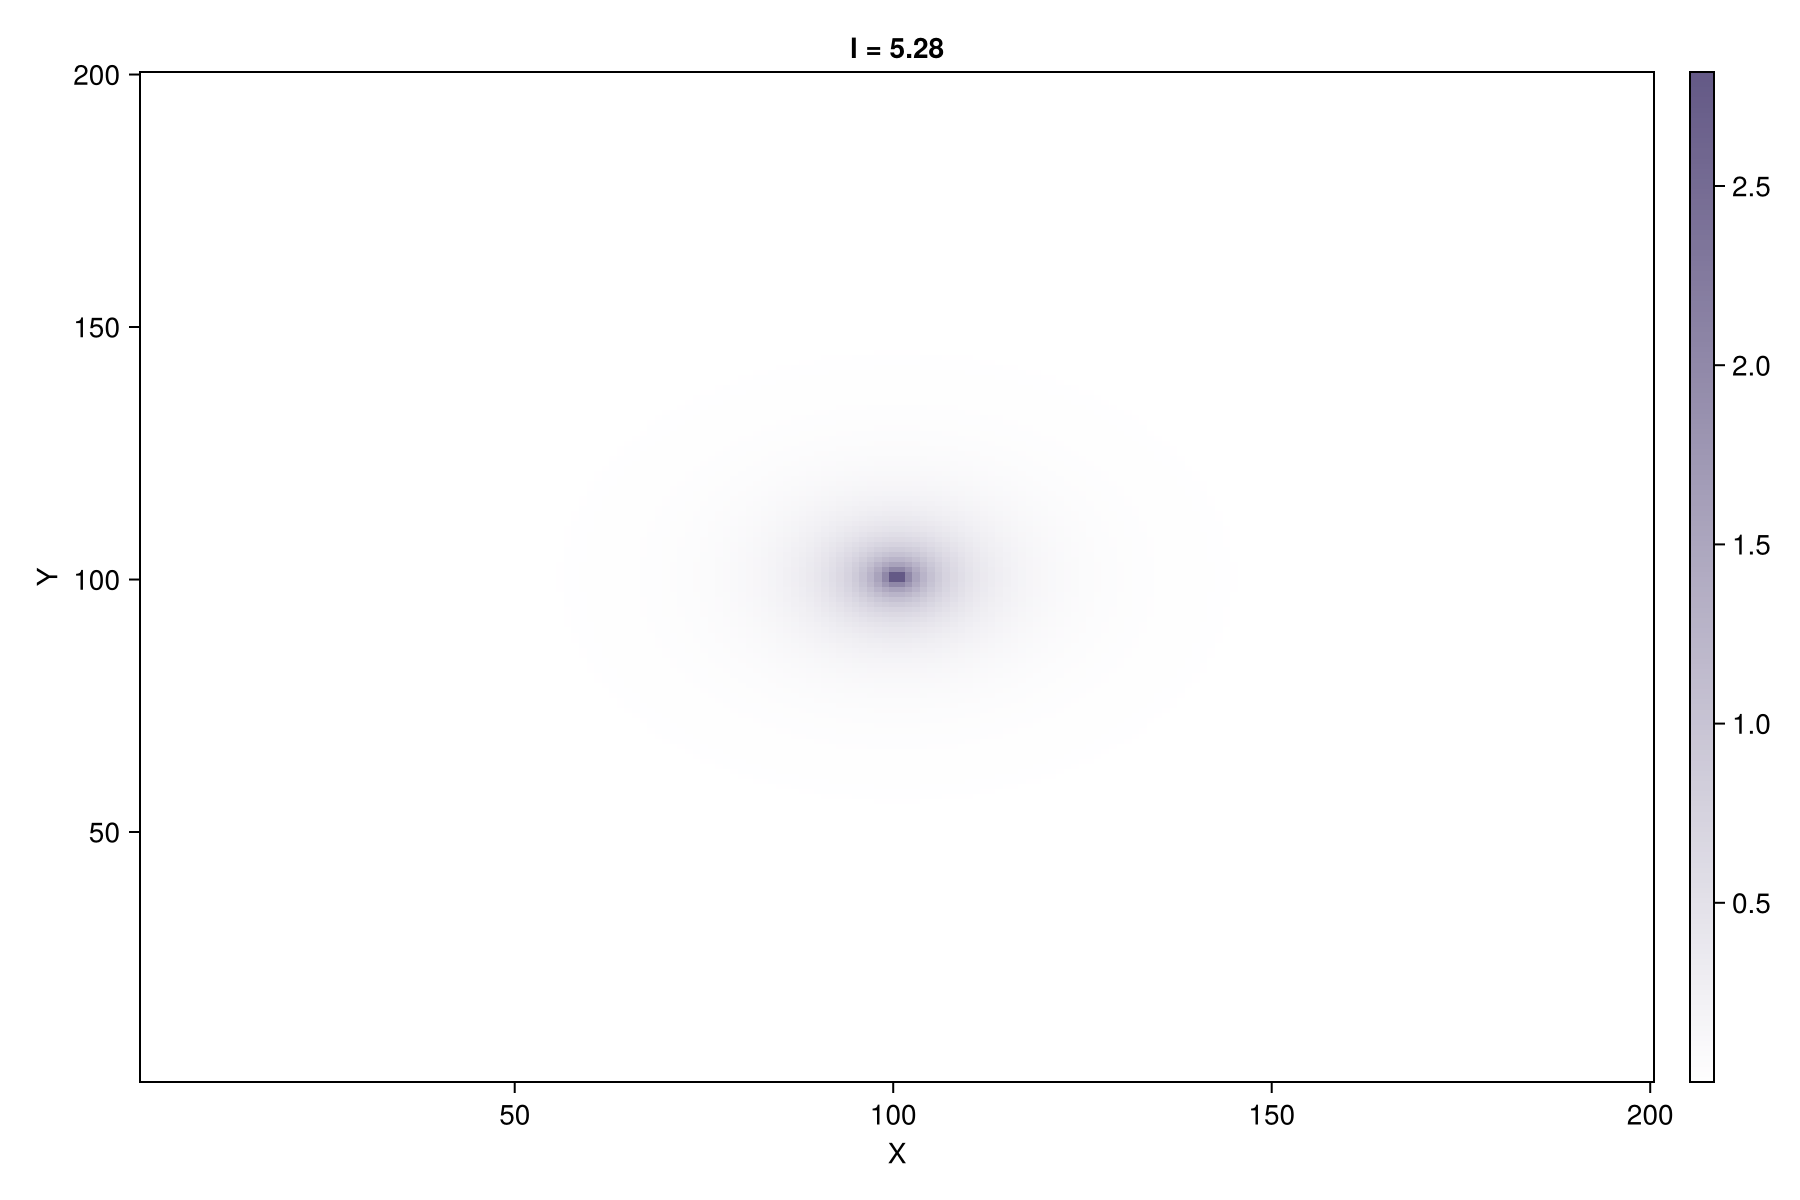

In [88]:
dark = colorant"#645986"
light = colorant"#F2EEF9"
white = colorant"#FFFFFF"
cmap = cgrad([white, dark])
xs, ys = 0.0, 0.0
len = 200

x_grid = range(-50, 50, length=len)
y_grid = range(-50, 50, length=len)

X, Y = meshgrid(x_grid, y_grid)

λ = sqrt(1.67 / 0.06)

r = sqrt.((X .- xs).^2 .+ (Y .- ys).^2)

mm_grid = @. 1.0 * besselk(0, r / λ)

fig2 = Figure(size=(900, 600))
ax2 = Axis(fig2[1,1], title = "l = $(round(λ, digits = 2))", xlabel = "X", ylabel = "Y")
hm = heatmap!(ax2, mm_grid, colormap = cmap)
Colorbar(fig2[1,2], hm, colorrange = (0,5))
# xlims!(50, 150)
# ylims!(50, 150)
fig2

In [89]:
save("Plots/Fixed_source_model/Next/l_field_n6.svg", fig2)

CairoMakie.Screen{SVG}


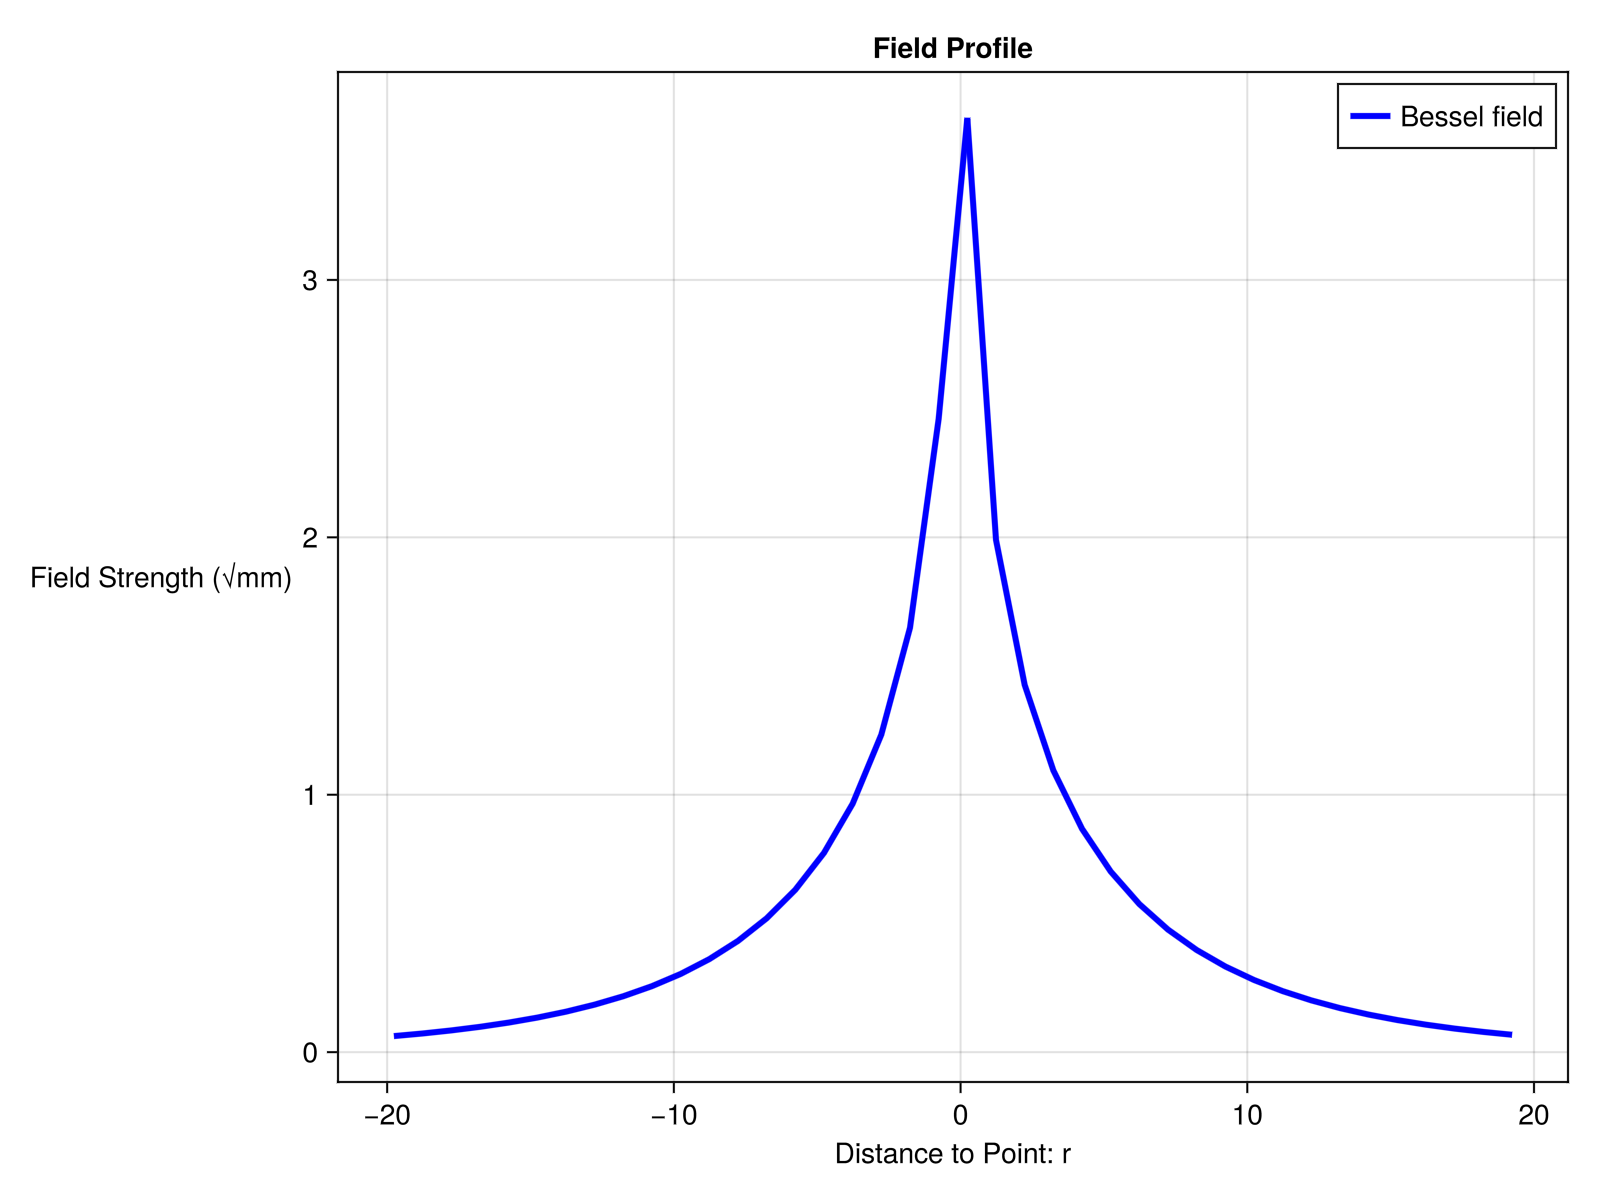

In [6]:
# --- 1. CONFIGURATION ---
mm_factor = 1.0
Dc = 2.5
delta = 0.04

ll = sqrt(Dc/delta)        # Effective length scale (l_eff)
r_max = 2.5 * ll        # Maximum distance to plot (e.g., 5 * ll)

x = -r_max:1:r_max

m_vals = mm_factor .* besselk.(0, abs.(x) ./ ll)


sqrt_m_vals = sqrt.(m_vals)

# --- 3. PLOTTING ---
fig = Figure(size = (800, 600), fontsize = 14)
ax = Axis(fig[1, 1], 
          title = "Field Profile",
          xlabel = "Distance to Point: r",
          ylabel = "Field Strength (√mm)",
          ylabelrotation = 0)

# Plot the line
lines!(ax, x, m_vals, 
       color = :blue, 
       linewidth = 3, 
       label = "Bessel field")



# Add legend
axislegend(ax, position = :rt)

# Display the figure
fig